<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/Business_Case_OLA_Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**OLA - Ensemble Learning Business Case Study**


**Dataset Explanation: ola_driver.csv**
1. MMMM-YY: Reporting month and year.
2. Driver_ID: A unique identifier for every driver.
3. Age: Age of the driver.
4. Gender: Driver's gender. Male: 0, Female: 1.
5. City: City code representing the city the driver operates in.
6. Education_Level: Education level of the driver, categorized into 0 for 10+, 1 for
12+, and 2 for graduate.
7. Income: Average monthly income of the driver.
8. Date Of Joining: The date when the driver joined Ola.
9. LastWorkingDate: The most recent or final day the driver worked with Ola.
10.Joining Designation: Designation of the driver at the onset of their journey with
Ola.
11. Grade: A grade assigned to the driver at the reporting time, likely denoting
performance or other metrics.
12.Total Business Value: The total monetary value (business) a driver brings in a
month. Negative values might indicate cancellations, refunds, or other financial
adjustments.
13.Quarterly Rating: Rating assigned to drivers on a quarterly basis. Ratings range
from 1 to 5, with 5 being the best.

**Problem Statement:**

The main aim is to predict potential
driver churn using multiple attributes to
maintain a consistent driver base and
ensure business continuity.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import figure
import statsmodels.api as sm
from scipy.stats import norm
from scipy.stats import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
Ola_df = pd.read_csv("/content/ola_driver_scaler.csv")
print(Ola_df.head())

   Unnamed: 0    MMM-YY  Driver_ID   Age  Gender City  Education_Level  \
0           0  01/01/19          1  28.0     0.0  C23                2   
1           1  02/01/19          1  28.0     0.0  C23                2   
2           2  03/01/19          1  28.0     0.0  C23                2   
3           3  11/01/20          2  31.0     0.0   C7                2   
4           4  12/01/20          2  31.0     0.0   C7                2   

   Income Dateofjoining LastWorkingDate  Joining Designation  Grade  \
0   57387      24/12/18             NaN                    1      1   
1   57387      24/12/18             NaN                    1      1   
2   57387      24/12/18        03/11/19                    1      1   
3   67016      11/06/20             NaN                    2      2   
4   67016      11/06/20             NaN                    2      2   

   Total Business Value  Quarterly Rating  
0               2381060                 2  
1               -665480                 

In [3]:
df = Ola_df.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [5]:
print(df.describe())

         Unnamed: 0     Driver_ID           Age        Gender  \
count  19104.000000  19104.000000  19043.000000  19052.000000   
mean    9551.500000   1415.591133     34.668435      0.418749   
std     5514.994107    810.705321      6.257912      0.493367   
min        0.000000      1.000000     21.000000      0.000000   
25%     4775.750000    710.000000     30.000000      0.000000   
50%     9551.500000   1417.000000     34.000000      0.000000   
75%    14327.250000   2137.000000     39.000000      1.000000   
max    19103.000000   2788.000000     58.000000      1.000000   

       Education_Level         Income  Joining Designation         Grade  \
count     19104.000000   19104.000000         19104.000000  19104.000000   
mean          1.021671   65652.025126             1.690536      2.252670   
std           0.800167   30914.515344             0.836984      1.026512   
min           0.000000   10747.000000             1.000000      1.000000   
25%           0.000000   42383.000

In [6]:
print(df.describe(include='object'))

          MMM-YY   City Dateofjoining LastWorkingDate
count      19104  19104         19104            1616
unique        24     29           869             493
top     01/01/19    C20      23/07/15        29/07/20
freq        1022   1008           192              70


In [7]:
df.shape

(19104, 14)

In [8]:
df.isna().sum()

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


**Insight**

There are 19104 entries with 14 columns

There are **61 null/missing values in Age, 52 in Gender and 17488 in *LastWorkingDate***

There are 2381 unique drivers

There are no duplicates

The column Unnamed: 0 can be dropped as it doesnt provide any new information

The columns Gender, City, Education_Level, Joining Designation, Grade and Quarterly Rating can be converted to categorical datatype

The columns MMM-YY, Dateofjoining and LastWorkingDate can be converted to datetime datatype

Drivers who have valid LastWorkingDate can be considered as churned

In [9]:
# Drop "Unnamed: 0" column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Convert to category
categorical_columns = ['Gender', 'City', 'Education_Level', 'Joining Designation', 'Grade']
df[categorical_columns] = df[categorical_columns].astype('category')
df['Gender'].replace({0.0:'Male', 1.0: 'Female'}, inplace=True)
df['Education_Level'].replace({0:'10+', 1:'12+', 2:'Graduate'}, inplace=True)

# Convert to datetime
df['MMM-YY'] = pd.to_datetime(df['MMM-YY'], format='%m/%d/%y')
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], format='%d/%m/%y')
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], format='%d/%m/%y')

# Rename 'MMM-YY' to 'ReportingMonthYear'
df.rename(columns={'MMM-YY':'ReportingMonthYear'}, inplace=True)
df['ReportingMonthYear'] = df['ReportingMonthYear'].dt.to_period('M')
df['ReportingYear'] = df['ReportingMonthYear'].dt.year

# Extract month and year from 'Dateofjoining'
df['Monthofjoining'] = df['Dateofjoining'].dt.month
df['Yearofjoining'] = df['Dateofjoining'].dt.year

# Find drivers who haved churned
df['Churn'] = df.groupby('Driver_ID')['LastWorkingDate'].transform('last')
df['Churn'] = df['Churn'].apply(lambda x: 0 if pd.isnull(x) else 1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   ReportingMonthYear    19104 non-null  period[M]     
 1   Driver_ID             19104 non-null  int64         
 2   Age                   19043 non-null  float64       
 3   Gender                19052 non-null  category      
 4   City                  19104 non-null  category      
 5   Education_Level       19104 non-null  category      
 6   Income                19104 non-null  int64         
 7   Dateofjoining         19104 non-null  datetime64[ns]
 8   LastWorkingDate       1616 non-null   datetime64[ns]
 9   Joining Designation   19104 non-null  category      
 10  Grade                 19104 non-null  category      
 11  Total Business Value  19104 non-null  int64         
 12  Quarterly Rating      19104 non-null  int64         
 13  ReportingYear   

Restructuring the data by aggregation

In [10]:
df.dtypes

,0
ReportingMonthYear,period[M]
Driver_ID,int64
Age,float64
Gender,category
City,category
Education_Level,category
Income,int64
Dateofjoining,datetime64[ns]
LastWorkingDate,datetime64[ns]
Joining Designation,category


In [11]:
# look at the top 5 rows
print(df.head(5))

  ReportingMonthYear  Driver_ID   Age Gender City Education_Level  Income  \
0            2019-01          1  28.0   Male  C23        Graduate   57387   
1            2019-02          1  28.0   Male  C23        Graduate   57387   
2            2019-03          1  28.0   Male  C23        Graduate   57387   
3            2020-11          2  31.0   Male   C7        Graduate   67016   
4            2020-12          2  31.0   Male   C7        Graduate   67016   

  Dateofjoining LastWorkingDate Joining Designation Grade  \
0    2018-12-24             NaT                   1     1   
1    2018-12-24             NaT                   1     1   
2    2018-12-24      2019-11-03                   1     1   
3    2020-06-11             NaT                   2     2   
4    2020-06-11             NaT                   2     2   

   Total Business Value  Quarterly Rating  ReportingYear  Monthofjoining  \
0               2381060                 2           2019              12   
1               -6

In [12]:
agg_df = df.groupby('Driver_ID').agg({
    'ReportingMonthYear' : len,
    'Age' : 'last',
    'Gender' : 'first',
    'City' : 'first',
    'Education_Level' : 'first',
    'Income' : 'last',
    'Dateofjoining' : 'first',
    'LastWorkingDate' : 'last',
    'Joining Designation' : 'first',
    'Grade' : 'last',
    'Total Business Value' : 'sum',
    'Quarterly Rating' : 'last',
    'Churn':'last'
}).reset_index()
agg_df.rename(columns={'ReportingMonthYear': 'Months of Service'}, inplace=True)
print(agg_df.head(10))

   Driver_ID  Months of Service   Age  Gender City Education_Level  Income  \
0          1                  3  28.0    Male  C23        Graduate   57387   
1          2                  2  31.0    Male   C7        Graduate   67016   
2          4                  5  43.0    Male  C13        Graduate   65603   
3          5                  3  29.0    Male   C9             10+   46368   
4          6                  5  31.0  Female  C11             12+   78728   
5          8                  3  34.0    Male   C2             10+   70656   
6         11                  1  28.0  Female  C19        Graduate   42172   
7         12                  6  35.0    Male  C23        Graduate   28116   
8         13                 23  31.0    Male  C19        Graduate  119227   
9         14                  3  39.0  Female  C26             10+   19734   

  Dateofjoining LastWorkingDate Joining Designation Grade  \
0    2018-12-24      2019-11-03                   1     1   
1    2020-06-11    

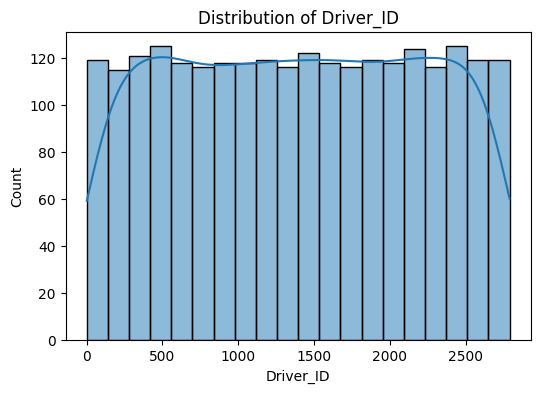

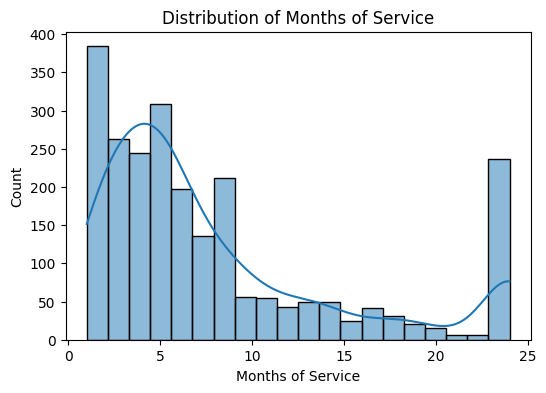

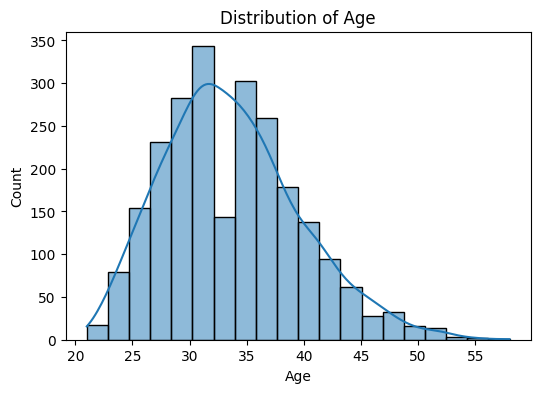

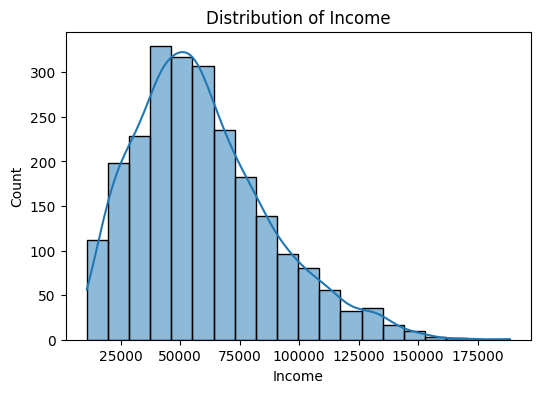

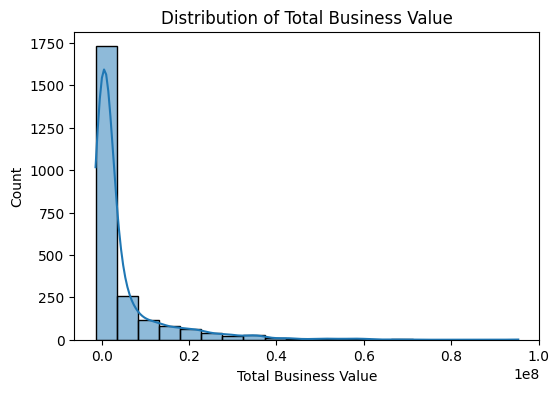

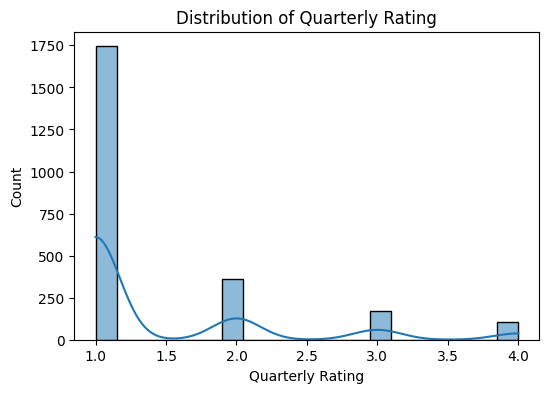

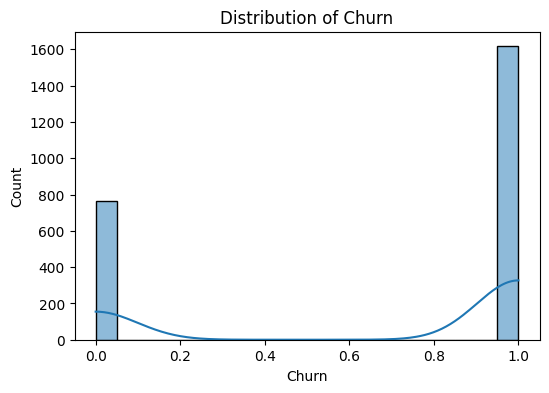

In [13]:
# Identifying Continuous and Categorical Variables
continuous_vars = agg_df.select_dtypes(include=['number']).columns.tolist()
categorical_vars = agg_df.select_dtypes(include=['object']).columns.tolist()

# Plot Continuous Variables (Histograms/Density Plots)
for var in continuous_vars:
    plt.figure(figsize=(6, 4))
    sns.histplot(agg_df[var], kde=True, bins=20)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.show()

# Plot Categorical Variables (Count Plots)
for var in categorical_vars:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=agg_df[var])
    plt.title(f'Count Plot of {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

Target variable creation:
target which tells whether the driver has left the company- driver whose last working day is present will have the value 1


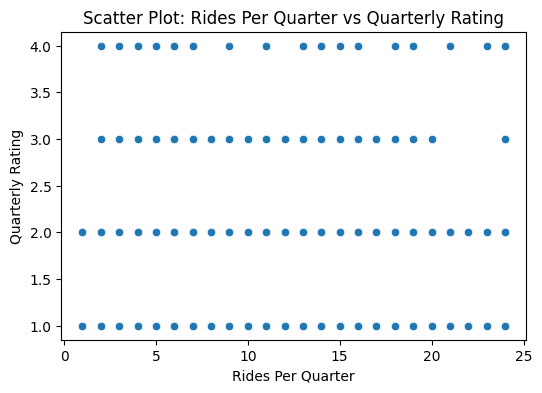

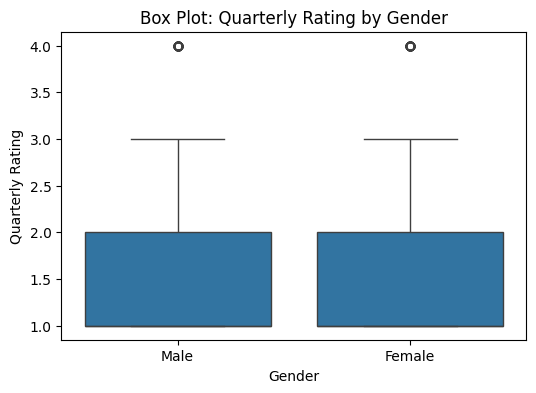

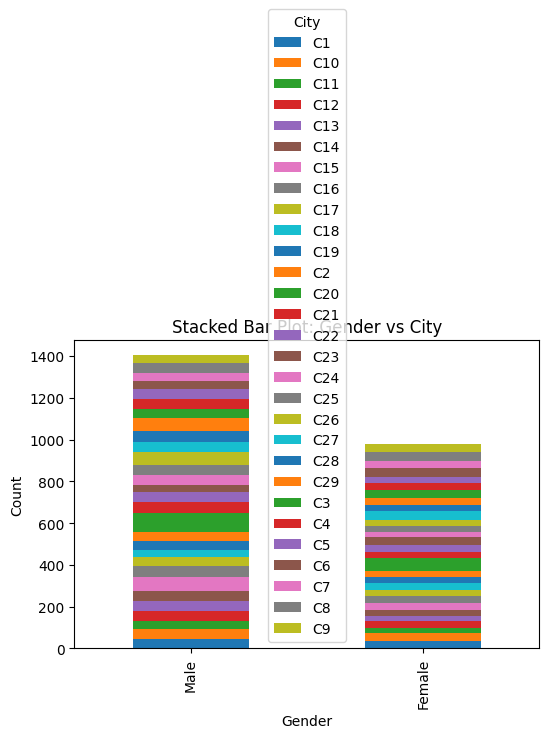

In [14]:
### Continuous-Continuous: Scatter Plots
plt.figure(figsize=(6, 4))
sns.scatterplot(x=agg_df['Months of Service'], y=agg_df['Quarterly Rating'])
plt.title('Scatter Plot: Rides Per Quarter vs Quarterly Rating')
plt.xlabel('Rides Per Quarter')
plt.ylabel('Quarterly Rating')
plt.show()

### Categorical-Continuous: Box Plots
plt.figure(figsize=(6, 4))
sns.boxplot(x=agg_df['Gender'], y=agg_df['Quarterly Rating'])
plt.title('Box Plot: Quarterly Rating by Gender')
plt.xlabel('Gender')
plt.ylabel('Quarterly Rating')
plt.show()

### Categorical-Categorical: Stacked Bar Plot
crosstab_df = pd.crosstab(agg_df['Gender'], agg_df['City'])
crosstab_df.plot(kind='bar', stacked=True, figsize=(6, 4))
plt.title('Stacked Bar Plot: Gender vs City')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title="City")
plt.show()

**Insight**

There are drivers from different age groups ranging from 21 to 58 years

Most of the drivers are in the age group of 30 to 35

The distribution is mostly normal with little skewness towards the right

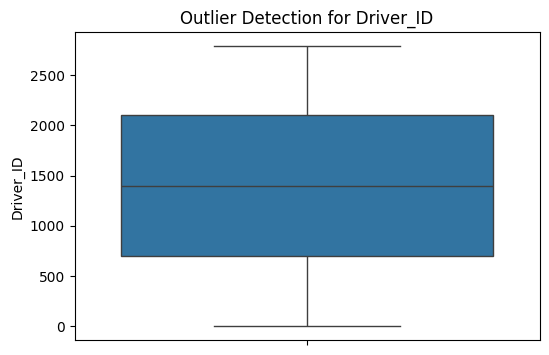

Outliers detected in Driver_ID: 0 observations


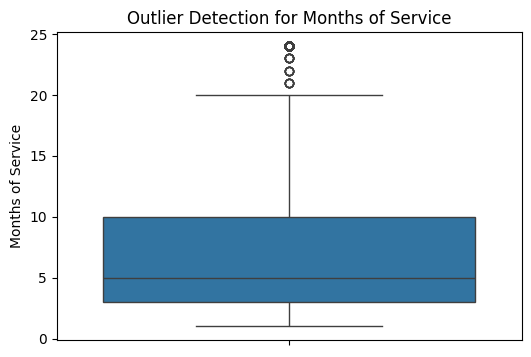

Outliers detected in Months of Service: 249 observations


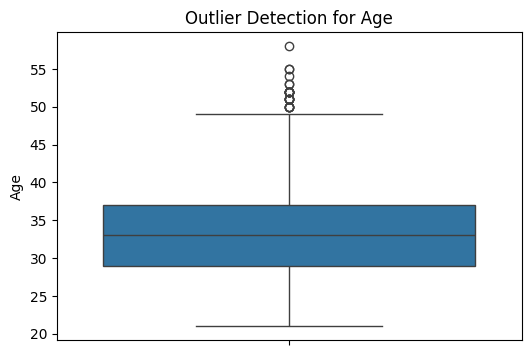

Outliers detected in Age: 25 observations


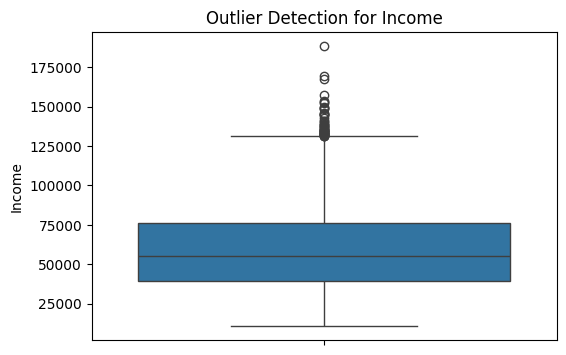

Outliers detected in Income: 48 observations


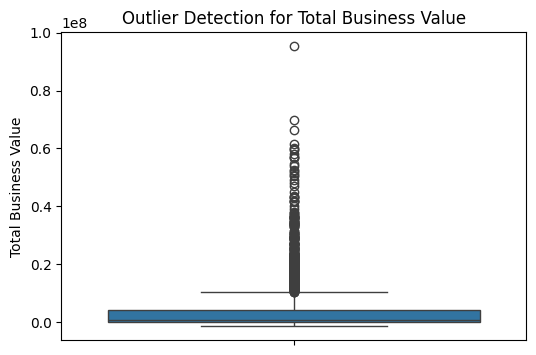

Outliers detected in Total Business Value: 336 observations


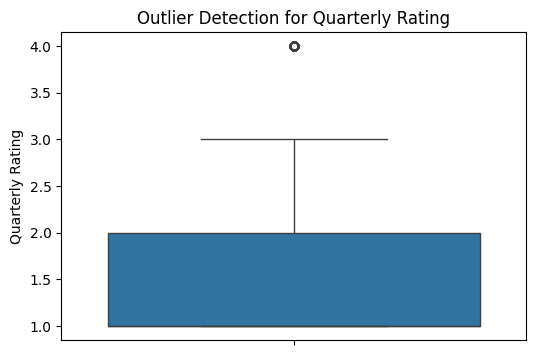

Outliers detected in Quarterly Rating: 107 observations


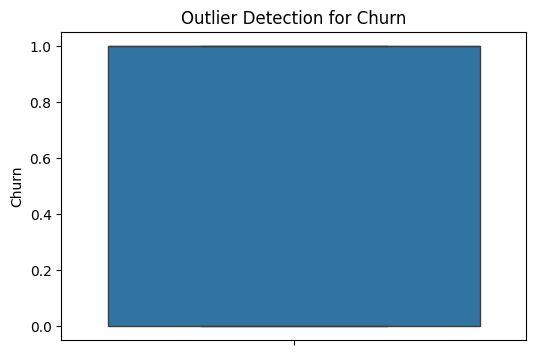

Outliers detected in Churn: 0 observations


In [15]:
# Outlier Detection using Box Plots and IQR
for cont in continuous_vars:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=agg_df[cont])
    plt.title(f"Outlier Detection for {cont}")
    plt.show()

    # Compute IQR
    Q1 = agg_df[cont].quantile(0.25)
    Q3 = agg_df[cont].quantile(0.75)
    IQR = Q3 - Q1

    # Define outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = agg_df[(agg_df[cont] < lower_bound) | (agg_df[cont] > upper_bound)]

    print(f"Outliers detected in {cont}: {len(outliers)} observations")



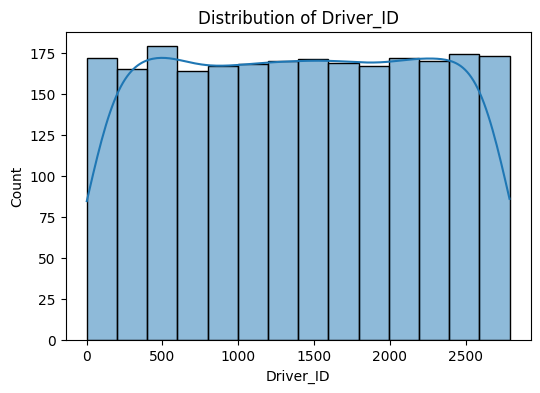

Skewness of Driver_ID: -0.00
Driver_ID is approximately normal.


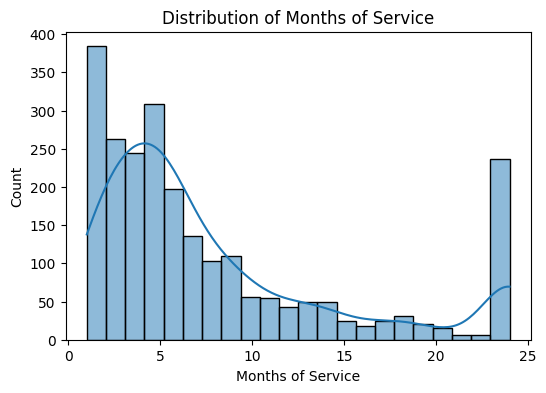

Skewness of Months of Service: 1.30
Months of Service is highly positively skewed.


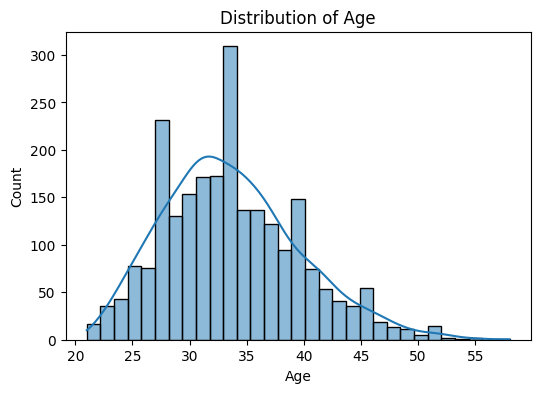

Skewness of Age: 0.54
Age is approximately normal.


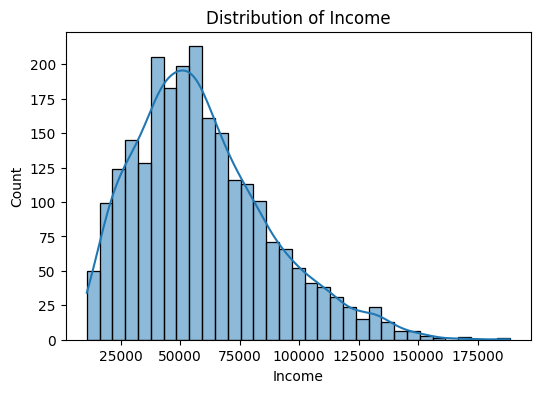

Skewness of Income: 0.78
Income is approximately normal.


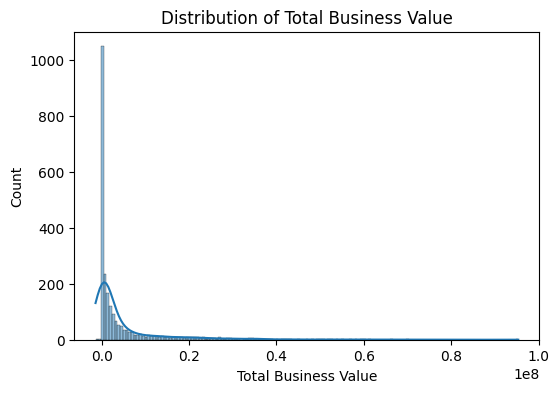

Skewness of Total Business Value: 3.36
Total Business Value is highly positively skewed.


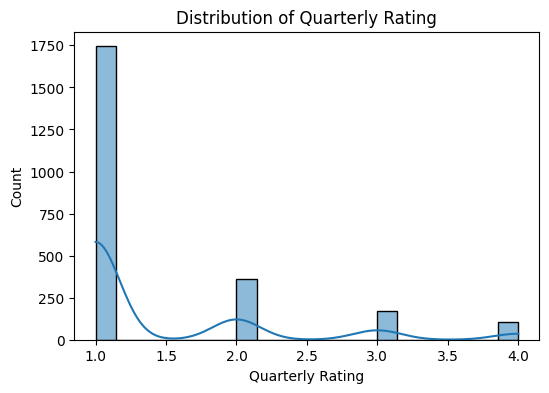

Skewness of Quarterly Rating: 1.90
Quarterly Rating is highly positively skewed.


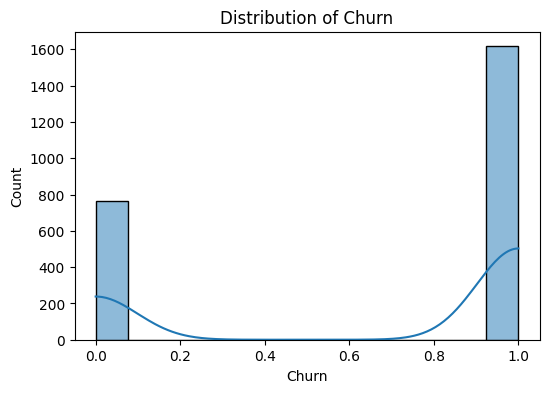

Skewness of Churn: -0.77
Churn is approximately normal.
Correlation Matrix:
                      Driver_ID  Months of Service       Age    Income  \
Driver_ID              1.000000           0.026467 -0.004458 -0.017876   
Months of Service      0.026467           1.000000  0.301765  0.275418   
Age                   -0.004458           0.301765  1.000000  0.210767   
Income                -0.017876           0.275418  0.210767  1.000000   
Total Business Value   0.015133           0.791473  0.263018  0.379468   
Quarterly Rating       0.012889           0.545020  0.150205  0.163429   
Churn                  0.029269          -0.345718 -0.078883 -0.201935   

                      Total Business Value  Quarterly Rating     Churn  
Driver_ID                         0.015133          0.012889  0.029269  
Months of Service                 0.791473          0.545020 -0.345718  
Age                               0.263018          0.150205 -0.078883  
Income                            0.379

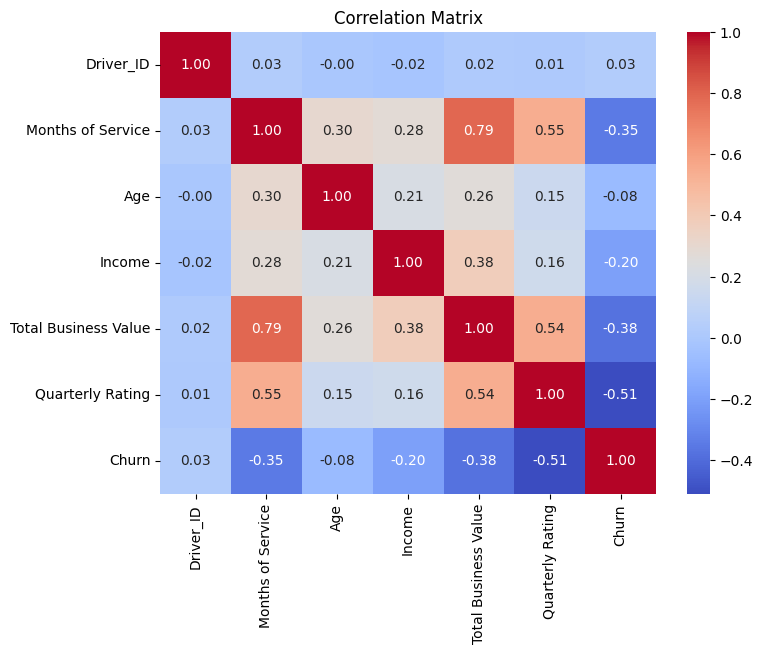

Correlation between Driver_ID and Months of Service: 0.03
Positive correlation observed.
Correlation between Driver_ID and Age: -0.00
Negative correlation observed.
Correlation between Driver_ID and Income: -0.02
Negative correlation observed.
Correlation between Driver_ID and Total Business Value: 0.02
Positive correlation observed.
Correlation between Driver_ID and Quarterly Rating: 0.01
Positive correlation observed.
Correlation between Driver_ID and Churn: 0.03
Positive correlation observed.
Correlation between Months of Service and Age: 0.30
Positive correlation observed.
Correlation between Months of Service and Income: 0.28
Positive correlation observed.
Correlation between Months of Service and Total Business Value: 0.79
Positive correlation observed.
Correlation between Months of Service and Quarterly Rating: 0.55
Positive correlation observed.
Correlation between Months of Service and Churn: -0.35
Negative correlation observed.
Correlation between Age and Income: 0.21
Positiv

In [16]:
# Identify normal vs skewed distributions
for cont in continuous_vars:
    plt.figure(figsize=(6, 4))
    sns.histplot(agg_df[cont], kde=True)
    plt.title(f"Distribution of {cont}")
    plt.show()

    skewness = stats.skew(agg_df[cont].dropna())
    print(f"Skewness of {cont}: {skewness:.2f}")
    if skewness > 1:
        print(f"{cont} is highly positively skewed.")
    elif skewness < -1:
        print(f"{cont} is highly negatively skewed.")
    else:
        print(f"{cont} is approximately normal.")

# Comment on relationships
correlation_matrix = agg_df[continuous_vars].corr()
print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

for i in range(len(continuous_vars)):
    for j in range(i + 1, len(continuous_vars)):
        corr_value = correlation_matrix.iloc[i, j]
        print(f"Correlation between {continuous_vars[i]} and {continuous_vars[j]}: {corr_value:.2f}")
        if corr_value > 0:
            print("Positive correlation observed.")
        elif corr_value < 0:
            print("Negative correlation observed.")
        else:
            print("No correlation observed.")


**Data Preprocessing**

In [17]:
# To get the count of duplicate rows
duplicate_count = agg_df.duplicated().sum()
duplicate_count

np.int64(0)

In [18]:
missing_values = agg_df.isnull().sum()

# To get columns with missing values
columns_with_missing = missing_values[missing_values > 0]

print("Columns with Missing Values:\n", columns_with_missing)

Columns with Missing Values:
 LastWorkingDate    765
dtype: int64


In [19]:
column_name=['Income','Months of Service','Quarterly Rating','Total Business Value',]

for col in column_name:
  # Define the percentile thresholds for capping (1st and 99th percentiles)
  lower_percentile = agg_df[col].quantile(0.01)  # 1st percentile
  upper_percentile = agg_df[col].quantile(0.99)  # 99th percentile

  # Apply capping to the column
  agg_df[col] = agg_df[col].clip(lower=lower_percentile, upper=upper_percentile)

  print("Capping applied to", col)

Capping applied to Income
Capping applied to Months of Service
Capping applied to Quarterly Rating
Capping applied to Total Business Value


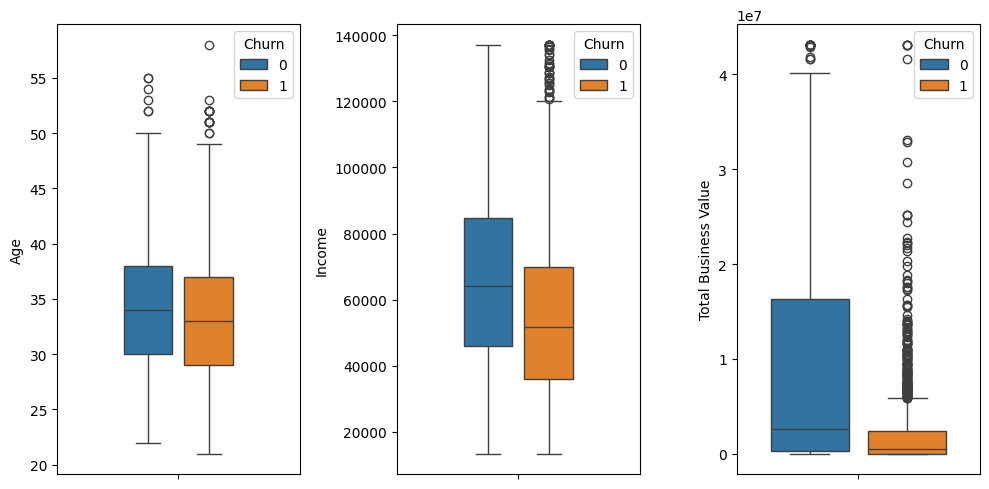

In [20]:
fig, axs = plt.subplots(1,3,figsize=(10,5))
sns.boxplot(ax=axs[0], data=agg_df, y='Age', hue='Churn', width=0.5, gap=0.2)
sns.boxplot(ax=axs[1], data=agg_df, y='Income', hue='Churn', width=0.5, gap=0.2)
sns.boxplot(ax=axs[2], data=agg_df, y='Total Business Value', hue='Churn', gap=0.2)
plt.tight_layout()
plt.show()


In [21]:
agg_df.isna().sum()

,0
Driver_ID,0
Months of Service,0
Age,0
Gender,0
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,765
Joining Designation,0


In [22]:
agg_df['Gender'].replace({'Male':0, 'Female':1}, inplace=True)
agg_df['Education_Level'].replace({'Graduate':0, '10+':1, '12+':2}, inplace=True)
agg_df['City'] = agg_df['City'].str[1:]

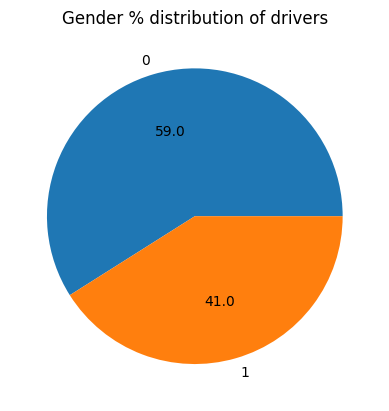

In [23]:
agg_df['Gender'].value_counts().plot(kind='pie', autopct='%.1f')
plt.title('Gender % distribution of drivers')
plt.ylabel('')
plt.show()

**Insight**

59% of the drivers are Male and remaining 41% are Female

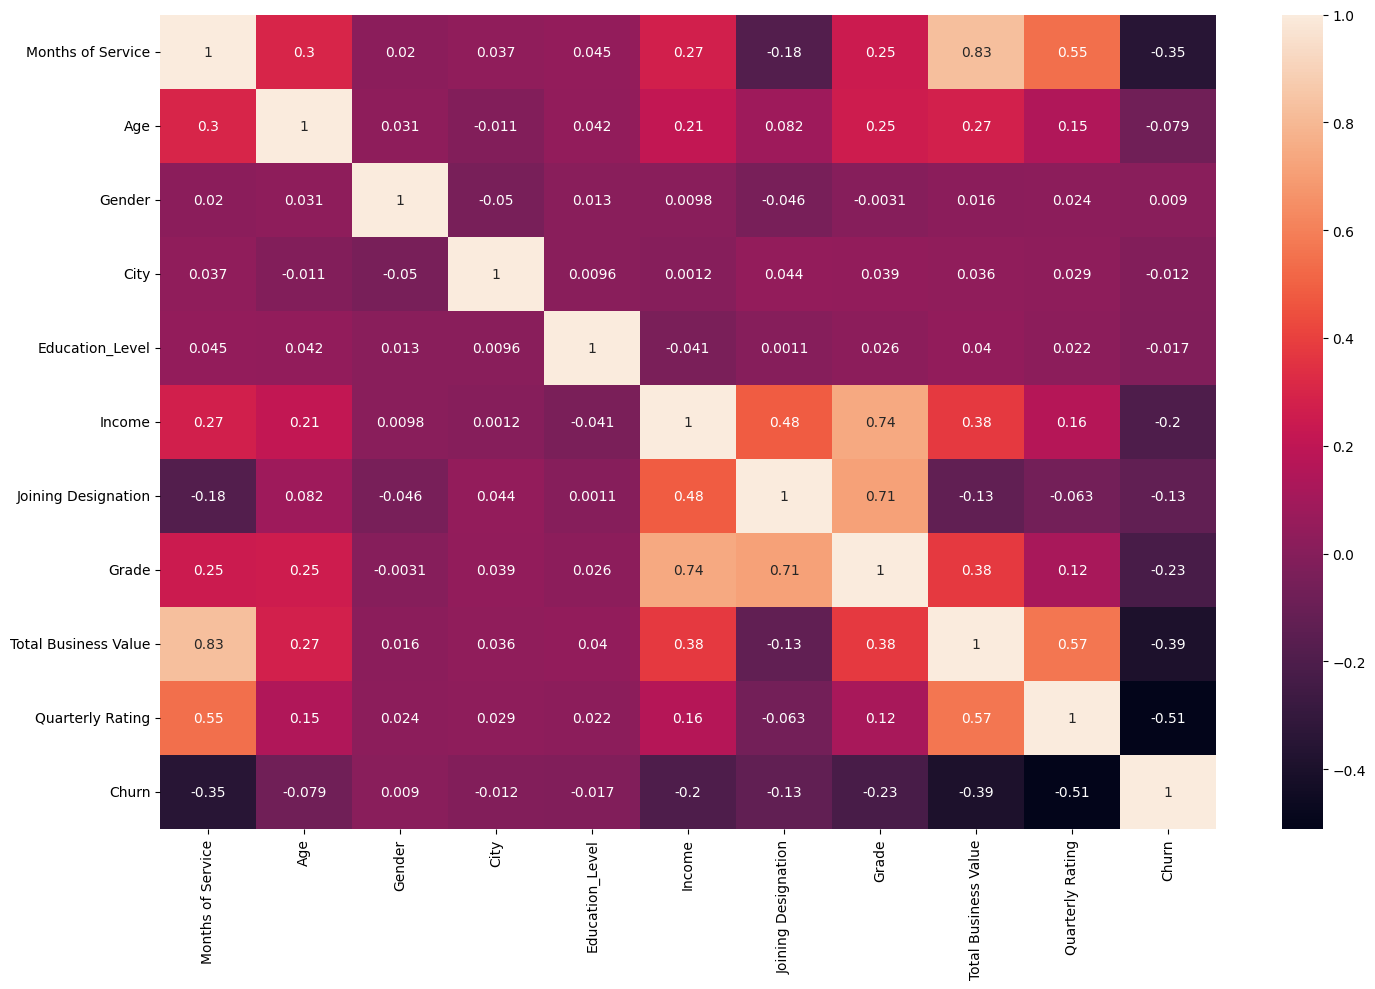

In [24]:
plt.figure(figsize=(15,10))
sns.heatmap(agg_df.drop(columns=['Driver_ID', 'Dateofjoining', 'LastWorkingDate']).corr(), annot=True)
plt.tight_layout()
plt.show()

In [25]:

agg_df['Quarterly Rating'] = agg_df['Quarterly Rating'].astype('category')
agg_df['Churn'] = agg_df['Churn'].astype('category')
print(agg_df.head())

   Driver_ID  Months of Service   Age Gender City Education_Level   Income  \
0          1                  3  28.0      0   23               0  57387.0   
1          2                  2  31.0      0    7               0  67016.0   
2          4                  5  43.0      0   13               0  65603.0   
3          5                  3  29.0      0    9               1  46368.0   
4          6                  5  31.0      1   11               2  78728.0   

  Dateofjoining LastWorkingDate Joining Designation Grade  \
0    2018-12-24      2019-11-03                   1     1   
1    2020-06-11             NaT                   2     2   
2    2019-07-12      2020-04-27                   2     2   
3    2019-09-01      2019-07-03                   1     1   
4    2020-07-31             NaT                   3     3   

   Total Business Value Quarterly Rating Churn  
0             1715580.0                2     1  
1                   0.0                1     0  
2              35

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor # Import the necessary function

In [27]:
features_df = agg_df.drop(columns=['Churn']) # Drop target column
# Ensure all columns are numeric before adding constant and calculating VIF
features_df = features_df.select_dtypes(include=np.number)  # Select only numeric columns
features_df = sm.add_constant(features_df)  # Adding a constant column for the intercept
vif_df = pd.DataFrame()
vif_df['Features'] = features_df.columns
vif_df['VIF'] = [variance_inflation_factor(features_df.values, idx) for idx in range(len(features_df.columns))]
vif_df['VIF'] = round(vif_df['VIF'], 2)
vif_df = vif_df.sort_values(by='VIF', ascending=False)
print(vif_df)

               Features    VIF
0                 const  39.36
5  Total Business Value   3.41
2     Months of Service   3.24
4                Income   1.19
3                   Age   1.12
1             Driver_ID   1.00


In [28]:
final_df = agg_df.copy()

Sepearte out target and feature columns

In [29]:
X = final_df.drop(columns=['Churn'])
y = final_df['Churn']
X.shape, y.shape

((2381, 13), (2381,))

Encode target variable

In [30]:
y = y.astype(int)

Encode features with just 2 classes as 0 or 1





In [31]:
print(final_df)

      Driver_ID  Months of Service   Age Gender City Education_Level   Income  \
0             1                  3  28.0      0   23               0  57387.0   
1             2                  2  31.0      0    7               0  67016.0   
2             4                  5  43.0      0   13               0  65603.0   
3             5                  3  29.0      0    9               1  46368.0   
4             6                  5  31.0      1   11               2  78728.0   
...         ...                ...   ...    ...  ...             ...      ...   
2376       2784                 24  34.0      0   24               1  82815.0   
2377       2785                  3  34.0      1    9               1  13425.0   
2378       2786                  9  45.0      0   19               1  35370.0   
2379       2787                  6  28.0      1   20               0  69498.0   
2380       2788                  7  30.0      0   27               0  70254.0   

     Dateofjoining LastWork

In [32]:
categorical_columns = X.select_dtypes(include='category').columns
categorical_columns

Index(['Gender', 'Education_Level', 'Joining Designation', 'Grade',
       'Quarterly Rating'],
      dtype='object')

In [33]:
from sklearn.preprocessing import OneHotEncoder # Import OneHotEncoder

In [34]:
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(X[categorical_columns])
encoded_df = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out(categorical_columns))
X = pd.concat([X, encoded_df], axis=1)
X.drop(columns = categorical_columns, inplace=True)
print(X.head())

   Driver_ID  Months of Service   Age City   Income Dateofjoining  \
0          1                  3  28.0   23  57387.0    2018-12-24   
1          2                  2  31.0    7  67016.0    2020-06-11   
2          4                  5  43.0   13  65603.0    2019-07-12   
3          5                  3  29.0    9  46368.0    2019-09-01   
4          6                  5  31.0   11  78728.0    2020-07-31   

  LastWorkingDate  Total Business Value  Gender_0  Gender_1  ...  \
0      2019-11-03             1715580.0       1.0       0.0  ...   
1             NaT                   0.0       1.0       0.0  ...   
2      2020-04-27              350000.0       1.0       0.0  ...   
3      2019-07-03              120360.0       1.0       0.0  ...   
4             NaT             1265000.0       0.0       1.0  ...   

   Joining Designation_5  Grade_1  Grade_2  Grade_3  Grade_4  Grade_5  \
0                    0.0      1.0      0.0      0.0      0.0      0.0   
1                    0.0      

Model building

Train-test split

In [35]:
from sklearn.model_selection import train_test_split # Import train_test_split from sklearn.model_selection

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1904, 27), (477, 27), (1904,), (477,))

Perform data normalization/standardization

Data before scaling

In [37]:
X_train.head()

,Driver_ID,Months of Service,Age,City,Income,Dateofjoining,LastWorkingDate,Total Business Value,Gender_0,Gender_1,...,Joining Designation_5,Grade_1,Grade_2,Grade_3,Grade_4,Grade_5,Quarterly Rating_1,Quarterly Rating_2,Quarterly Rating_3,Quarterly Rating_4
2236,2618,7,28.0,20,57164.0,2020-01-05,2020-11-27,1092560.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,11,1,28.0,19,42172.0,2020-07-12,NaT,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1818,2138,1,29.0,8,43989.0,2018-07-30,2019-05-01,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1534,1805,7,40.0,19,59636.0,2020-05-29,NaT,2589640.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2123,2490,6,25.0,25,29052.0,2019-11-21,2020-11-04,2172260.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Data after scaling

In [38]:
X_train.head()

,Driver_ID,Months of Service,Age,City,Income,Dateofjoining,LastWorkingDate,Total Business Value,Gender_0,Gender_1,...,Joining Designation_5,Grade_1,Grade_2,Grade_3,Grade_4,Grade_5,Quarterly Rating_1,Quarterly Rating_2,Quarterly Rating_3,Quarterly Rating_4
2236,2618,7,28.0,20,57164.0,2020-01-05,2020-11-27,1092560.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,11,1,28.0,19,42172.0,2020-07-12,NaT,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1818,2138,1,29.0,8,43989.0,2018-07-30,2019-05-01,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1534,1805,7,40.0,19,59636.0,2020-05-29,NaT,2589640.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2123,2490,6,25.0,25,29052.0,2019-11-21,2020-11-04,2172260.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Check for imbalance in target class

In [39]:
y_train.value_counts(normalize=True)*100

,proportion
Churn,
1,68.644958
0,31.355042


class 1 is the driviers who churned . 68%
class 0 is the driviers who have not churned . 32%
Data is imbalanced

Converting date columns into Datatime format :

In [40]:
!pip install scikit-learn --upgrade
!pip install -U imbalanced-learn

In [41]:
from imblearn.over_sampling import SMOTE

# Assuming 'Dateofjoining', 'LastWorkingDate' are the columns with Timestamp values
# Drop these columns before applying SMOTE
columns_to_drop = ['Dateofjoining', 'LastWorkingDate']  # Add any other columns with Timestamp as needed
X_train_numeric = X_train.drop(columns=columns_to_drop, errors='ignore') # errors='ignore' to avoid errors if columns already dropped
X_test_numeric = X_test.drop(columns=columns_to_drop, errors='ignore')
# Apply SMOTE
sm = SMOTE(random_state=0)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_numeric, y_train)

# If you need the dropped columns back, add them to the resampled data
# (assuming they are not needed for training)
# X_train_resampled = pd.concat([X_train_resampled, X_train[columns_to_drop]], axis=1)

# Continue with your model training using X_train_resampled and y_train_resampled
y_train_resampled.value_counts(normalize=True)*100

,proportion
Churn,
1,50.0
0,50.0


6.3. Ensemble Learning: Bagging - RandomForestClassifier

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
RF = RandomForestClassifier(n_estimators=100,
 criterion='entropy',
 max_depth=10,
 min_samples_split=2,
 min_samples_leaf=1,
 min_weight_fraction_leaf=0.0,
 max_features='sqrt',
 max_leaf_nodes=None,
 min_impurity_decrease=0.0,
 bootstrap=True,
 oob_score=False,
 n_jobs=None,
 random_state=None,
 verbose=0,
 warm_start=False,
 class_weight="balanced",
 ccp_alpha=0.0085,
 max_samples=None,)


In [44]:
RF.fit(X_train_resampled, y_train_resampled)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",0.0085
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_featu

In [45]:

# Calculate and print scores using the modified test data
RF.score(X_train_resampled, y_train_resampled), RF.score(X_test_numeric,y_test)

(0.8477429227237949, 0.7987421383647799)

In [46]:
RF.feature_importances_

array([2.10047149e-03, 1.64145873e-01, 5.41533238e-03, 8.92703401e-04,
       8.40567435e-03, 8.87773499e-02, 4.94935289e-03, 3.18116850e-03,
       1.01564258e-02, 9.48330242e-03, 2.17876941e-03, 5.48165325e-02,
       2.06757091e-02, 4.49952669e-02, 1.59759410e-04, 0.00000000e+00,
       3.51840085e-02, 2.96247156e-02, 5.58254269e-02, 8.53944807e-04,
       3.05863423e-04, 2.84846499e-01, 9.03112579e-02, 5.31250674e-02,
       2.95895259e-02])

In [47]:
X.columns

Index(['Driver_ID', 'Months of Service', 'Age', 'City', 'Income',
       'Dateofjoining', 'LastWorkingDate', 'Total Business Value', 'Gender_0',
       'Gender_1', 'Education_Level_0', 'Education_Level_1',
       'Education_Level_2', 'Joining Designation_1', 'Joining Designation_2',
       'Joining Designation_3', 'Joining Designation_4',
       'Joining Designation_5', 'Grade_1', 'Grade_2', 'Grade_3', 'Grade_4',
       'Grade_5', 'Quarterly Rating_1', 'Quarterly Rating_2',
       'Quarterly Rating_3', 'Quarterly Rating_4'],
      dtype='object')

<Axes: >

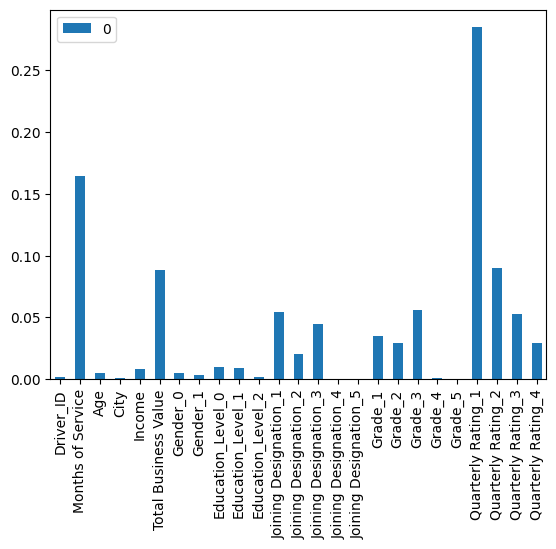

In [48]:
pd.DataFrame(data=RF.feature_importances_,
             index=X_train_resampled.columns).plot(kind="bar")

In [49]:
from sklearn.metrics import f1_score , precision_score, recall_score,confusion_matrix

In [50]:
confusion_matrix(y_test,RF.predict(X_test_numeric) )

array([[100,  68],
       [ 28, 281]])

In [51]:
X_train_for_prediction = X_train.drop(columns=['Dateofjoining', 'LastWorkingDate'], errors='ignore')

In [52]:
confusion_matrix(y_train, RF.predict(X_train_for_prediction))

array([[ 371,  226],
       [ 109, 1198]])

In [53]:
RF.score(X_train_resampled, y_train_resampled), RF.score(X_test_numeric,y_test)

(0.8477429227237949, 0.7987421383647799)

In [54]:
confusion_matrix(y_test,RF.predict(X_test_numeric) )

array([[100,  68],
       [ 28, 281]])

In [55]:
confusion_matrix(y_train, RF.predict(X_train_numeric))

array([[ 371,  226],
       [ 109, 1198]])

In [56]:
f1_score(y_test,RF.predict(X_test_numeric)),f1_score(y_train,RF.predict(X_train_numeric))

(0.8541033434650456, 0.8773343097766386)

In [57]:
precision_score(y_test,RF.predict(X_test_numeric)),precision_score(y_train,RF.predict(X_train_numeric))


(0.8051575931232091, 0.8412921348314607)

In [58]:
recall_score(y_test,RF.predict(X_test_numeric)),recall_score(y_train,RF.predict(X_train_numeric))

(0.9093851132686084, 0.9166029074215761)

GridSearchCV - on RandomForestClassifier

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
parameters = {"max_depth":[7,10,15],
 "n_estimators":[100,200,300,400],
 "max_features":[4,7,10],
 "ccp_alpha":[0.0005,0.00075,0.001]}
RFC = RandomForestClassifier()
grid_search = GridSearchCV(
 estimator = RFC,
 param_grid = parameters,
 scoring = "accuracy",
 n_jobs = -1,
 refit=True, # need not to train again after grid search
 cv=3,
 pre_dispatch='2*n_jobs',
 return_train_score=False)


In [60]:

grid_search.fit(X_train_resampled, y_train_resampled.values.ravel())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.0005, 0.00075, ...], 'max_depth': [7, 10, ...], 'max_features': [4, 7, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ver

In [61]:
grid_search.best_estimator_


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",7
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",0.0005
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weig

In [62]:
grid_search.best_score_

np.float64(0.8584872040643642)

In [63]:
grid_search.best_params_

{'ccp_alpha': 0.0005, 'max_depth': 15, 'max_features': 7, 'n_estimators': 400}

In [64]:
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(n_estimators=100,
 criterion='entropy',
 max_depth=7,
 min_samples_split=2,
 min_samples_leaf=1,

 class_weight="balanced",
 ccp_alpha=0.0001,
 max_samples=None)


In [65]:
RF.fit(X_train_numeric, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",0.0001
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_featur

In [66]:
RF.score(X_train_resampled, y_train_resampled),RF.score(X_test_numeric,y_test)

(0.8320581484315226, 0.8155136268343816)

In [67]:
y_test_pred = RF.predict(X_test_numeric)
y_train_pred = RF.predict(X_train_resampled)

In [68]:
f1_score(y_test,y_test_pred),f1_score(y_train_resampled,y_train_pred)

(0.8620689655172413, 0.8450405930109425)

In [69]:
precision_score(y_test,y_test_pred),precision_score(y_train_resampled,y_train_pred)

(0.8358662613981763, 0.7844036697247706)

In [70]:
recall_score(y_test,y_test_pred),recall_score(y_train_resampled,y_train_pred)

(0.889967637540453, 0.9158377964804897)

BaggingClassifier

In [71]:
from sklearn.tree import DecisionTreeClassifier

In [72]:
from sklearn.ensemble import BaggingClassifier

In [73]:
from xgboost import XGBClassifier

In [74]:
from sklearn.model_selection import RandomizedSearchCV

**Insights**

Most of the drivers are in the age group of 30 to 35

59% of the drivers are Male and remaining 41% are Female

City C20 has the maximum number of drivers

Maximum number of drivers joined in the year 2020 and in the month of July

1026 drivers have a joining designation of 1

Maximum number of drivers have a grade of 2

Majority of the drivers have a very low quarterly rating of 1

There are no drivers with quarterly rating of 5

1616 drivers have churned, which is around 68%

The median income of drivers who have churned is lesser than that of the drivers who have not churned



**8. Recommendation**

The quartely rating has been the top contibutor on deciding if a driver will churn or not.

As the ratings are given by the customers to the driver, Ola should urge all customers to rate the drivers on time. Ola should provide incentives/points to the customers to encourage timely rating.

Ola should make sure that the income of deserving drivers should be increased every 6 months, if not every quarter, to encourage drivers to stay

Long service awards/bonuses should be given to drivers to keep them motivated

Special trainings should be given to drivers on how to handle different customers and different situations so that the customers always provide positive ratings.